In [2]:
import pandas as pd

In [3]:
# Data Types

# 1. Series: A one-dimensional labeled array capable of holding any data type (integers, strings, floating point numbers, Python objects, etc.). It can be thought of as a column in a spreadsheet or a SQL table.
car_brands = pd.Series(['Toyota', 'Honda', 'Ford'])

colors = pd.Series(['Red', 'Blue', 'Black'])


# 2. DataFrame: A two-dimensional labeled data structure with columns of potentially different types. It can be thought of as a spreadsheet or a SQL table, or a dictionary of Series objects.
car_data = pd.DataFrame({'Car Brand': car_brands, 'Color': colors})
car_data

,Car Brand,Color
0,Toyota,Red
1,Honda,Blue
2,Ford,Black


#### Manually Creating DataFrame
- we can manually create a `DataFrame`. Using a Python dictionary of lists. 
- the `keys` will be used as **column headers** 
- and the `values` in each list will as the columns of the DataFrame

In [4]:
df = pd.DataFrame({
    "Name": ['Alice', 'Bob', 'Charlie', 'David'],
    "Age": [25, 30, 35, 40],
    "Sex": ['Female', 'Male', 'Male', 'Male']
})
df

,Name,Age,Sex
0,Alice,25,Female
1,Bob,30,Male
2,Charlie,35,Male
3,David,40,Male


### Each column in a `DataFrame` is a `Series`
- Selecting multiple columns returns a DataFrame, while selecting a single column returns a Series.


In [14]:
print(df['Age'][0:2])
print(df['Sex'])
print(df[['Name', 'Sex']]) 
print(df['Sex'][0])


0    25
1    30
Name: Age, dtype: int64
0    Female
1      Male
2      Male
3      Male
Name: Sex, dtype: str
      Name     Sex
0    Alice  Female
1      Bob    Male
2  Charlie    Male
3    David    Male
Female


### Performing some functions on the columns of DataFrame

you can do things with a DataFrame (table) or Series (each column of a DF).<br>
pandas has a lot of functionalities and each of them is a method that can be applied to a DataFrame/Series<br>
As methods are functions use `()` <br>


- min()
- max()
- boolean conditions
- slicing
- describe()
The describe() method provides a quick overview of the numerical data in a DataFrame. As the Name and Sex columns are textual data, these are by default not taken into account by the describe() method.


In [15]:
# Do something with the DataFrame of series
print(df['Age'].min())
print(df['Age'].max())
print(df['Age'][0] < 10) # False
print(df[['Name', 'Age']][0:2]) # Get first two rows of Name and Age columns

df.describe() # Get summary statistics of the DataFrame

25
40
False
    Name  Age
0  Alice   25
1    Bob   30


,Age
count,4.000000
mean,32.500000
std,6.454972
min,25.000000
25%,28.750000
50%,32.500000
75%,36.250000
max,40.000000


In [18]:
# Importing Data
car_sales = pd.read_csv('./data/car-sales.csv')
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [27]:
# dtypes
print(car_sales.dtypes)
car_columns = car_sales.columns
print(car_columns)
print(car_sales.index)
car_sales.info()
car_sales.mean(numeric_only=True) # Get mean of numeric columns
car_sales['Odometer (KM)'].sum() # Get sum of odometer column

Make               str
Colour             str
Odometer (KM)    int64
Doors            int64
Price              str
dtype: object
Index(['Make', 'Colour', 'Odometer (KM)', 'Doors', 'Price'], dtype='str')
RangeIndex(start=0, stop=10, step=1)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Make           10 non-null     str  
 1   Colour         10 non-null     str  
 2   Odometer (KM)  10 non-null     int64
 3   Doors          10 non-null     int64
 4   Price          10 non-null     str  
dtypes: int64(2), str(3)
memory usage: 532.0 bytes


np.int64(786014)

In [29]:
car_sales.head()
car_sales.tail()

,Make,Colour,Odometer (KM),Doors,Price
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [ ]:
animals = pd.Series(['cat', 'dog', None, 'rabbit'], index=['a', 'b', 'a', 'd'])

print(animals.loc['a']) # label based indexing, returns all values with label 'a'
print(animals.iloc[0]) # postion based indexing, returns the first value in the series


a    cat
a    NaN
dtype: str
cat


In [ ]:
# Filtering Data
car_sales[car_sales['Make'] == 'Toyota'] # Filter rows where Make is Toyota
car_sales[car_sales['Doors'] > 4] # Filter rows where Doors is greater than 4


,Make,Colour,Odometer (KM),Doors,Price
3,BMW,Black,11179,5,"$22,000.00"


In [ ]:
# Grouping Data

# Create a cross-tabulation of Make and Doors
pd.crosstab(car_sales['Make'], car_sales['Doors'])

# Filter rows where Make is Toyota and Colour is White, then group by Doors
car_sales[(car_sales['Make'] == 'Toyota') & (car_sales['Colour'] == 'White')].groupby('Doors').mean(numeric_only=True) # Group by Doors and get mean of numeric columns

# Filter rows where Make is Toyota and Colour is White
car_sales[(car_sales['Make'] == 'Toyota') & (car_sales['Colour'] == 'White')]



,Odometer (KM)
Doors,
4,105021.5


In [83]:
import matplotlib.pyplot as plt

0     4000.0
1     5000.0
2     7000.0
3    22000.0
4     3500.0
5     4500.0
6     7500.0
7     7000.0
8     6250.0
9     9700.0
Name: Price (USD), dtype: float64


<Axes: ylabel='Frequency'>

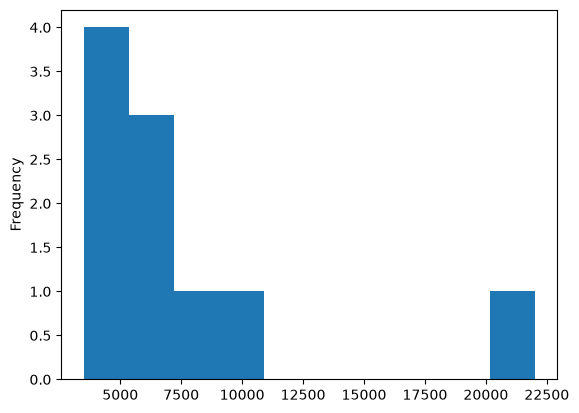

In [107]:
# remove $ sign
# car_sales['Price'] = car_sales['Price'].str.replace('[\$\,]', '', regex=True).astype(float)

# change column name
car_sales.rename(columns={'Price': 'Price (USD)'}, inplace=True) 

print(car_sales['Price (USD)'])
car_sales['Price (USD)'].plot(kind='hist') # Plot histogram of Price column


#### Manipulating Data


In [114]:
car_sales

,Make,Colour,Odometer (KM),Doors,Price (USD)
0,toyota,white,150043,4,4000.0
1,honda,red,87899,4,5000.0
2,toyota,blue,32549,3,7000.0
3,bmw,black,11179,5,22000.0
4,nissan,white,213095,4,3500.0
5,toyota,green,99213,4,4500.0
6,honda,blue,45698,4,7500.0
7,honda,blue,54738,4,7000.0
8,toyota,white,60000,4,6250.0
9,nissan,white,31600,4,9700.0


In [113]:
car_sales['Make'] = car_sales['Make'].str.lower()
car_sales['Colour'] = car_sales['Colour'].str.lower()

In [118]:
# Missing Data
car_sales_missing = pd.read_csv('./data/car-sales-missing-data.csv')
car_sales_missing

,Make,Colour,Odometer,Doors,Price
0,Toyota,White,150043.0,4.0,"$4,000"
1,Honda,Red,87899.0,4.0,"$5,000"
2,Toyota,Blue,NaN,3.0,"$7,000"
3,BMW,Black,11179.0,5.0,"$22,000"
4,Nissan,White,213095.0,4.0,"$3,500"
5,Toyota,Green,NaN,4.0,"$4,500"
6,Honda,NaN,NaN,4.0,"$7,500"
7,Honda,Blue,NaN,4.0,NaN
8,Toyota,White,60000.0,NaN,NaN
9,NaN,White,31600.0,4.0,"$9,700"


In [ ]:
# Fill missing data
car_sales_missing['Odometer'].fillna(0) 

0    150043.0
1     87899.0
2         NaN
3     11179.0
4    213095.0
5         NaN
6         NaN
7         NaN
8     60000.0
9     31600.0
Name: Odometer, dtype: float64

In [ ]:
# Create data from existing data

# Column from series # does not need to be same length as the DataFrame
seats_column = pd.Series([5, 5, 5, 5, 5])
# New column called seats in car_sales DataFrame
car_sales['Seats'] = seats_column
car_sales

,Make,Colour,Odometer (KM),Doors,Price (USD),Seats
0,toyota,white,150043,4,4000.0,5.0
1,honda,red,87899,4,5000.0,5.0
2,toyota,blue,32549,3,7000.0,5.0
3,bmw,black,11179,5,22000.0,5.0
4,nissan,white,213095,4,3500.0,5.0
5,toyota,green,99213,4,4500.0,NaN
6,honda,blue,45698,4,7500.0,NaN
7,honda,blue,54738,4,7000.0,NaN
8,toyota,white,60000,4,6250.0,NaN
9,nissan,white,31600,4,9700.0,NaN


In [ ]:
# Column from python list # needs to be same length as the DataFrame
fuel_economy = [7.5, 8.0, 6.5, 7.0, 8.5,7.5, 8.0, 6.5, 7.0, 8.5]
car_sales['Fuel Economy (L/100km)'] = fuel_economy
car_sales

,Make,Colour,Odometer (KM),Doors,Price (USD),Seats,Fuel Economy (L/100km)
0,toyota,white,150043,4,4000.0,5.0,7.5
1,honda,red,87899,4,5000.0,5.0,8.0
2,toyota,blue,32549,3,7000.0,5.0,6.5
3,bmw,black,11179,5,22000.0,5.0,7.0
4,nissan,white,213095,4,3500.0,5.0,8.5
5,toyota,green,99213,4,4500.0,NaN,7.5
6,honda,blue,45698,4,7500.0,NaN,8.0
7,honda,blue,54738,4,7000.0,NaN,6.5
8,toyota,white,60000,4,6250.0,NaN,7.0
9,nissan,white,31600,4,9700.0,NaN,8.5


In [130]:
# Column from a column
car_sales['Total Fuel Used (L)'] = car_sales['Odometer (KM)'] / 100 * car_sales['Fuel Economy (L/100km)']
car_sales

,Make,Colour,Odometer (KM),Doors,Price (USD),Seats,Fuel Economy (L/100km),Total Fuel Used (L)
0,toyota,white,150043,4,4000.0,5.0,7.5,11253.225
1,honda,red,87899,4,5000.0,5.0,8.0,7031.920
2,toyota,blue,32549,3,7000.0,5.0,6.5,2115.685
3,bmw,black,11179,5,22000.0,5.0,7.0,782.530
4,nissan,white,213095,4,3500.0,5.0,8.5,18113.075
5,toyota,green,99213,4,4500.0,NaN,7.5,7440.975
6,honda,blue,45698,4,7500.0,NaN,8.0,3655.840
7,honda,blue,54738,4,7000.0,NaN,6.5,3557.970
8,toyota,white,60000,4,6250.0,NaN,7.0,4200.000
9,nissan,white,31600,4,9700.0,NaN,8.5,2686.000


In [ ]:
# Column from a single value
car_sales['Wheels'] = 4
car_sales

# Column from a list comprehension
car_sales['Passed road safety'] = pd.Series([True if x%2 == 0 else False for x in range(len(car_sales))])
car_sales


,Make,Colour,Odometer (KM),Doors,Price (USD),Seats,Fuel Economy (L/100km),Total Fuel Used (L),Wheels,Passed road safety
0,toyota,white,150043,4,4000.0,5.0,7.5,11253.225,4,True
1,honda,red,87899,4,5000.0,5.0,8.0,7031.920,4,False
2,toyota,blue,32549,3,7000.0,5.0,6.5,2115.685,4,True
3,bmw,black,11179,5,22000.0,5.0,7.0,782.530,4,False
4,nissan,white,213095,4,3500.0,5.0,8.5,18113.075,4,True
5,toyota,green,99213,4,4500.0,NaN,7.5,7440.975,4,False
6,honda,blue,45698,4,7500.0,NaN,8.0,3655.840,4,True
7,honda,blue,54738,4,7000.0,NaN,6.5,3557.970,4,False
8,toyota,white,60000,4,6250.0,NaN,7.0,4200.000,4,True
9,nissan,white,31600,4,9700.0,NaN,8.5,2686.000,4,False


In [136]:
# Drop columns
car_sales.drop('Wheels', axis=1)

,Make,Colour,Odometer (KM),Doors,Price (USD),Seats,Fuel Economy (L/100km),Total Fuel Used (L),Passed road safety
0,toyota,white,150043,4,4000.0,5.0,7.5,11253.225,True
1,honda,red,87899,4,5000.0,5.0,8.0,7031.920,False
2,toyota,blue,32549,3,7000.0,5.0,6.5,2115.685,True
3,bmw,black,11179,5,22000.0,5.0,7.0,782.530,False
4,nissan,white,213095,4,3500.0,5.0,8.5,18113.075,True
5,toyota,green,99213,4,4500.0,NaN,7.5,7440.975,False
6,honda,blue,45698,4,7500.0,NaN,8.0,3655.840,True
7,honda,blue,54738,4,7000.0,NaN,6.5,3557.970,False
8,toyota,white,60000,4,6250.0,NaN,7.0,4200.000,True
9,nissan,white,31600,4,9700.0,NaN,8.5,2686.000,False


In [142]:
# Shuffling the rows of a DataFrame
car_sales.sample(frac=1) # Shuffle all rows


,Make,Colour,Odometer (KM),Doors,Price (USD),Seats,Fuel Economy (L/100km),Total Fuel Used (L),Wheels,Passed road safety
5,toyota,green,99213,4,4500.0,NaN,7.5,7440.975,4,False
8,toyota,white,60000,4,6250.0,NaN,7.0,4200.000,4,True
2,toyota,blue,32549,3,7000.0,5.0,6.5,2115.685,4,True
1,honda,red,87899,4,5000.0,5.0,8.0,7031.920,4,False
4,nissan,white,213095,4,3500.0,5.0,8.5,18113.075,4,True
3,bmw,black,11179,5,22000.0,5.0,7.0,782.530,4,False
6,honda,blue,45698,4,7500.0,NaN,8.0,3655.840,4,True
7,honda,blue,54738,4,7000.0,NaN,6.5,3557.970,4,False
0,toyota,white,150043,4,4000.0,5.0,7.5,11253.225,4,True
9,nissan,white,31600,4,9700.0,NaN,8.5,2686.000,4,False
